In [7]:
import os

CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

In [1]:
import pandas as pd
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

DATA_PATH = "dataset/"

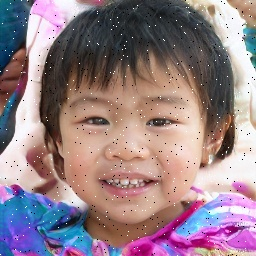

In [2]:
from PIL import Image

img = Image.open(f"{DATA_PATH}/train_images/124.jpg")
img

In [3]:
labels = pd.read_csv(DATA_PATH + '/train_solution.csv')

labels.rename(columns={'0': 'id', '0.1': 'label'}, inplace=True)
labels[:5]

,id,label
0,1,1
1,2,1
2,3,0
3,4,0
4,5,0


Предобработка датасета

Выборочный блюр по битым пикселям, перед реализацией проверим что они распределены с равной вероятностью по классам

In [68]:
#noise_ratio = (количество битых пикселей) / (общее число пикселей)
noise_ratios = []

for _, row in labels[:1000].iterrows():
    img_path = DATA_PATH + "train_images/" + str(row["id"]) + ".jpg"
    img = np.array(Image.open(img_path))

    # маска salt & pepper
    salt = np.all(img >= 200, axis=-1)
    pepper = np.all(img <= 40, axis=-1)
    noise_mask = np.logical_or(salt, pepper)

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_img = cv2.medianBlur(img_gray, 3)
    diff = abs(img_gray.astype(np.int16) - blur_img.astype(np.int16))
        
    diff_mask = diff > 30

    mask = np.logical_and(diff_mask, noise_mask)

    noise_ratio = mask.sum() / mask.size
    noise_ratios.append(noise_ratio)

noise_df = labels.iloc[:1000].copy()
noise_df["noise_ratio"] = noise_ratios

In [69]:
noise_df.groupby('label')["noise_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,506.0,0.021105,0.012781,0.000275,0.010250,0.019852,0.031521,0.054794
1,494.0,0.022546,0.013031,0.000443,0.011459,0.021286,0.033272,0.049210


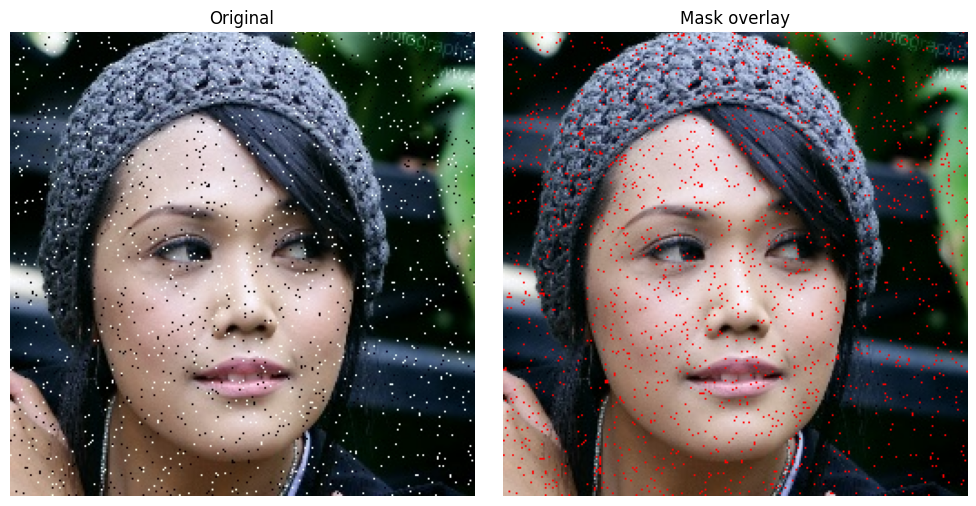

In [70]:
import matplotlib.pyplot as plt
fi = Image.open(img_path)
vis = img.copy()
vis[mask] = [255, 0, 0]
vis_img = Image.fromarray(vis.astype(np.uint8))
vis_img.show()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(fi)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(vis_img)
plt.title("Mask overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
class ImageDataset(Dataset):
    def __init__(self, images_dir, labels_csv, transform=None):
        """
        images_dir: путь к папке с изображениями
        labels_csv: CSV с колонками [id, label]
        transform: опциональные преобразования (torchvision / albumentations)
        """
        self.images_dir = images_dir
        self.labels = labels_csv
        self.transform = transform
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]
        img_name = row["id"]
        label = row["label"]

        img_path = os.path.join(self.images_dir, f"{img_name}.jpg")
        
        img = np.array(Image.open(img_path))

        salt = np.all(img >= 200, axis=-1)
        pepper = np.all(img <= 40, axis=-1)
        noise_mask = np.logical_or(salt, pepper)

        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_img = cv2.medianBlur(img_gray, 3)
        diff = abs(img_gray.astype(np.int16) - blur_img.astype(np.int16))
        
        diff_mask = diff > 30

        mask = np.logical_and(diff_mask, noise_mask)
        blur_rgb = cv2.medianBlur(img, 3)

        img[mask] = blur_rgb[mask]
        img = Image.fromarray(img.astype(np.uint8))
        if self.transform:
            img = self.transform(img)

        return img, label

Расчет значений для нормализации

In [77]:
pixels = 0
rgb = np.zeros(3)
rgb_sq = np.zeros(3)

for _, row in labels[:20000].iterrows():
    img_path = DATA_PATH + "train_images/" + str(row["id"]) + ".jpg"
    img = np.array(Image.open(img_path)) / 255.0

    h, w, z = img.shape
    
    rgb += img.reshape(-1, 3).sum(axis=0)
    rgb_sq += (img.reshape(-1, 3)**2).sum(axis=0)
    pixels += h * w

mean = rgb / pixels
std = np.sqrt(rgb_sq / pixels - mean ** 2)

print("mean:", mean)
print("std:", std)

mean: [0.51959995 0.42806779 0.38476987]
std: [0.28506448 0.26334668 0.26321086]


In [5]:
transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=[0.5195, 0.428, 0.3847], std=[0.285, 0.2633, 0.2632])
])
dataset = ImageDataset(images_dir=(DATA_PATH + "train_images/"), labels_csv=labels, transform=transform)

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])

train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
val_dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

In [8]:
for images, labels in train_dataloader:
  print("Батч изображений:", images.shape)
  print("Батч меток:", labels)
  break 

Батч изображений: torch.Size([16, 3, 224, 224])
Батч меток: tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


используем pre-trained модель и метод fine-tuning, чтобы убедиться что все работает, данные предобработаны корректно, модель будет учиться

In [9]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
    
model.eval()                     # backbone в eval
for param in model.fc.parameters():
    param.requires_grad = True

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2
)

In [11]:
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model's state_dict:
conv1.weight 	 torch.Size([64, 3, 7, 7])
bn1.weight 	 torch.Size([64])
bn1.bias 	 torch.Size([64])
bn1.running_mean 	 torch.Size([64])
bn1.running_var 	 torch.Size([64])
bn1.num_batches_tracked 	 torch.Size([])
layer1.0.conv1.weight 	 torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight 	 torch.Size([64])
layer1.0.bn1.bias 	 torch.Size([64])
layer1.0.bn1.running_mean 	 torch.Size([64])
layer1.0.bn1.running_var 	 torch.Size([64])
layer1.0.bn1.num_batches_tracked 	 torch.Size([])
layer1.0.conv2.weight 	 torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight 	 torch.Size([64])
layer1.0.bn2.bias 	 torch.Size([64])
layer1.0.bn2.running_mean 	 torch.Size([64])
layer1.0.bn2.running_var 	 torch.Size([64])
layer1.0.bn2.num_batches_tracked 	 torch.Size([])
layer1.1.conv1.weight 	 torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight 	 torch.Size([64])
layer1.1.bn1.bias 	 torch.Size([64])
layer1.1.bn1.running_mean 	 torch.Size([64])
layer1.1.bn1.running_var 	 torch.Size([64])
layer1.1.bn1.num_batc

In [65]:
from sklearn.metrics import f1_score

@torch.inference_mode()
def mini_val(model, loss_fn, dataloader, device, n_batches):
    model.eval()
    total_loss = 0
    y_pred, y_true = [], []
    for i, (x, y) in enumerate(dataloader):
        if i >= n_batches:
            break
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        
        total_loss += loss.item()
        preds = output.argmax(dim=1)
        y_pred.append(preds)
        y_true.append(y)
    
    y_pred = torch.cat(y_pred)
    y_true = torch.cat(y_true)
    
    acc = (y_pred == y_true).float().mean().item()
    loss = total_loss / n_batches
    f1 = f1_score(y_true.numpy(), y_pred.numpy())
    
    return loss, acc, f1        

In [66]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def live_plot(history):
    clear_output(wait=True)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].plot(history["loss"])
    axs[0].set_title("Val Loss")

    axs[1].plot(history["acc"])
    axs[1].set_title("Val Accuracy")

    axs[2].plot(history["f1"])
    axs[2].set_title("Val F1")

    plt.show()

In [ ]:
ckpt = torch.load("checkpoints/step_500.pt", map_location=device)

model.load_state_dict(ckpt["model_state"])
optimizer.load_state_dict(ckpt["optimizer_state"])

global_step = ckpt["global_step"]
start_epoch = ckpt["epoch"]

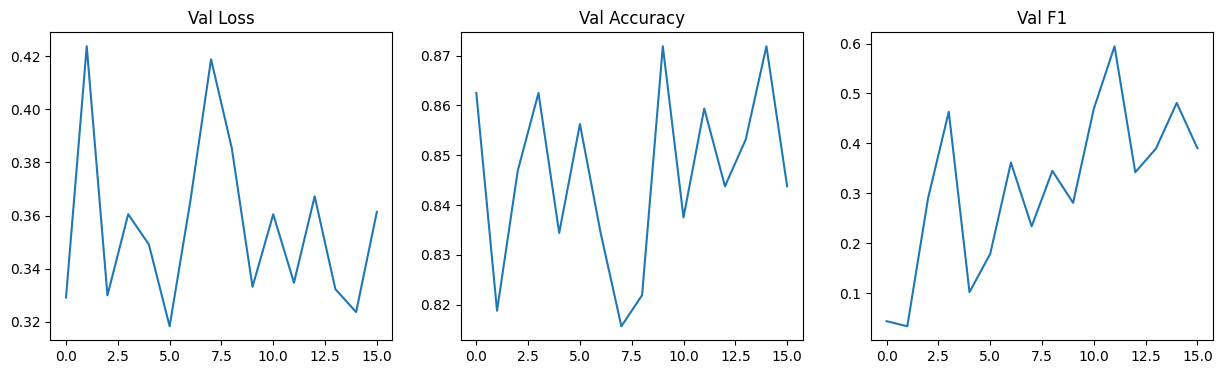

batch:  6400


KeyboardInterrupt: 

In [67]:
history = {"loss": [], "acc": [], "f1": []}
global_step = 0

for epoch in range(10):
    print("epoch ", epoch)
    #train
    model.fc.train() 
    
    for image, label in train_dataloader:
        if global_step % 50 == 0:
            print("batch: ", global_step)
        image, label = image.to(device), label.to(device)
        
        optimizer.zero_grad()        
        y_pred = model(image)
        loss = loss_fn(y_pred, label)
        loss.backward()
        optimizer.step()
        global_step += 1
        
        if global_step % 400 == 0 and global_step != 0:
            val_loss, val_acc, val_f1 = mini_val(model, loss_fn, val_dataloader, device, n_batches=20)
            print(val_loss, val_acc, val_f1)

            history["loss"].append(val_loss)
            history["acc"].append(val_acc)
            history["f1"].append(val_f1)
        
            live_plot(history)
            
            ckpt_path = os.path.join(CKPT_DIR, f"step_{global_step}.pt")
            torch.save({
                "epoch": epoch,
                "global_step": global_step,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict()
            }, ckpt_path)
            
            model.fc.train() 
        
            

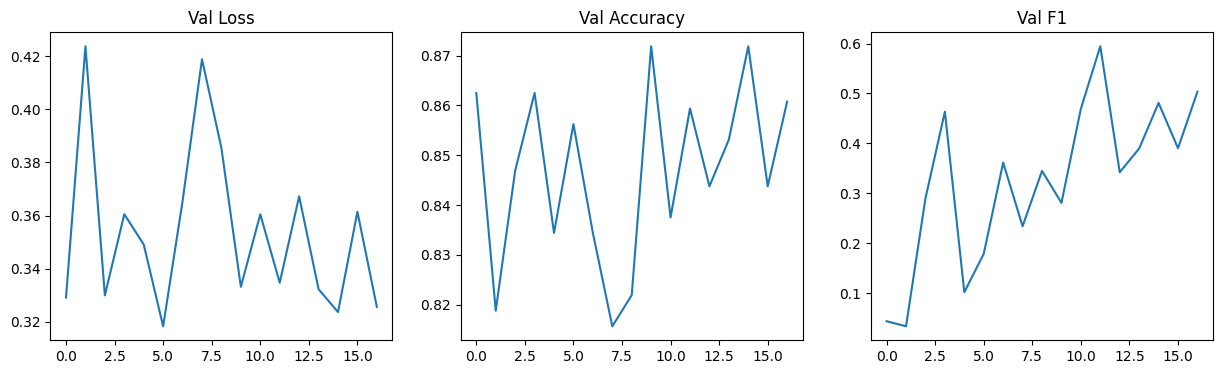

0.32563432009518145 0.8607500195503235 0.5035650623885918


In [68]:
val_loss, val_acc, val_f1 = mini_val(model, loss_fn, val_dataloader, device, n_batches=500)
history["loss"].append(val_loss)
history["acc"].append(val_acc)
history["f1"].append(val_f1)
        
live_plot(history)
print(val_loss, val_acc, val_f1)

In [34]:
start_epoch = 0
global_step = 0
CHECKPOINT_DIR = "\Users\User\.cache\torch\hub\checkpoints\"
if os.path.exists(CHECKPOINT_PATH):
    print("Loading checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    if "scheduler" in checkpoint and checkpoint["scheduler"] is not None:
        scheduler.load_state_dict(checkpoint["scheduler"])

    start_epoch = checkpoint["epoch"]
    global_step = checkpoint["global_step"]

    print(f"Resumed from epoch {start_epoch}, step {global_step}")
else:
    print("No checkpoint found, starting from scratch")

SyntaxError: unterminated string literal (detected at line 3) (3768002596.py, line 3)

In [12]:
@torch.inference_mode()
def mini_evaluate(model, data_loader, loss_fn, device, max_batches):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for i, (x, y) in enumerate(data_loader):
        if i >= max_batches:
            break

        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_fn(out, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total_samples += x.size(0)

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )

In [16]:
from tqdm import tqdm

def train(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    optimizer,
    loss_fn,
    device: torch.device,
    val_every_n_batches: int = 100,
    max_val_batches: int = 5
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (image, label) in enumerate(tqdm(train_loader)):
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(image)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()
x`
        total_loss += loss.item() * image.size(0)
        total_correct += (output.argmax(dim=1) == label).sum().item()
        total_samples += image.size(0)

        # ---- мини-валидация ----
        if (batch_idx + 1) % (val_every_n_batches * 2) == 0:
            global_step += 1
            val_loss, val_acc = mini_evaluate(
                model,
                valid_loader,
                loss_fn,
                device,
                max_batches=max_val_batches
            )

            print(
                f"\n[Mini-val @ batch {batch_idx+1}] "
                f"loss={val_loss:.4f}, acc={val_acc:.4f}\n"
            )

            model.train()  # ВАЖНО: вернуть режим обучения

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )


In [17]:
@torch.inference_mode()
def evaluate(model, data_loader, loss_fn, device):
    model.eval()
    total_loss, total_correct = 0, 0

    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_fn(out, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (out.argmax(1) == y).sum().item()

    return (
        total_loss / len(data_loader.dataset),
        total_correct / len(data_loader.dataset)
    )

In [ ]:
global_step = 0

def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title, model_name):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        print("epoch ", epoch)
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": loss_fn
            }, f"checkpoints/{model_name}_{epoch}.pth")

In [15]:
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()